In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [17]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu


In [18]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [19]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

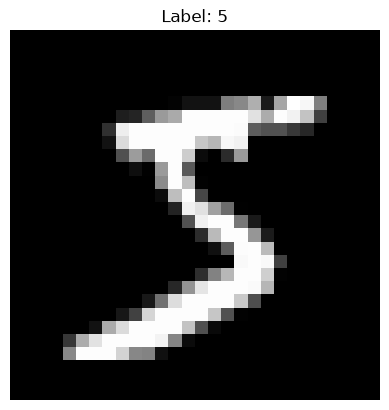

In [20]:
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [21]:
class MNISTModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [22]:
model = MNISTModel()

print(model)

MNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [23]:
criterion = nn.CrossEntropyLoss()

In [24]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [25]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.3442 Accuracy: 90.43%
Epoch [2/5] Loss: 0.1405 Accuracy: 95.84%
Epoch [3/5] Loss: 0.0962 Accuracy: 97.06%
Epoch [4/5] Loss: 0.0727 Accuracy: 97.73%
Epoch [5/5] Loss: 0.0560 Accuracy: 98.19%


In [26]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.54%


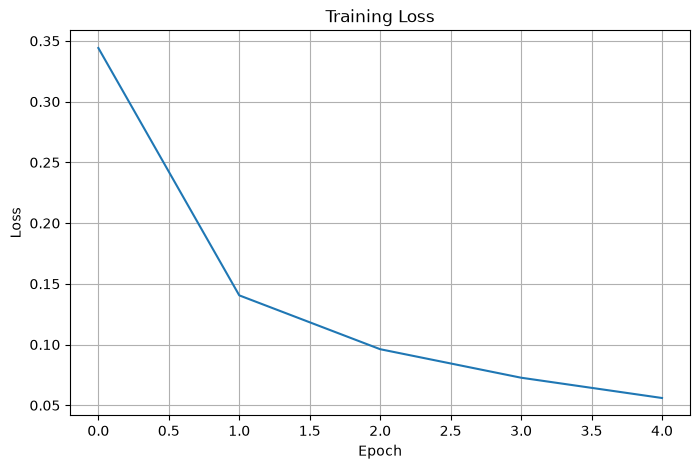

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

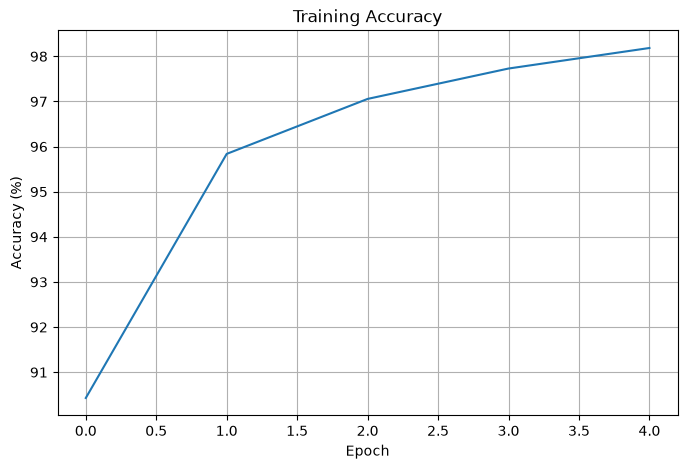

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid()
plt.show()

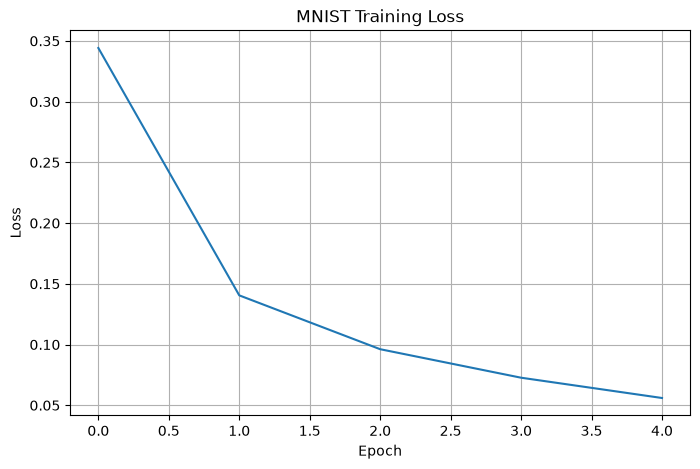

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training Loss")

plt.grid()

plt.savefig("training_curves.png")

plt.show()

In [30]:
torch.save(
    model.state_dict(),
    "mnist_model.pth"
)

print("Model saved!")

Model saved!


In [31]:
image, label = test_dataset[0]

model.eval()

with torch.no_grad():

    output = model(image.unsqueeze(0))

    prediction = torch.argmax(output, dim=1).item()

print("Actual digit:", label)
print("Predicted digit:", prediction)

Actual digit: 7
Predicted digit: 7
